# Benchmarking the Pfaffian strategies

This notebook benchmarks the available Pfaffian strategies in terms of **time** and **memory** for both the **forward** and **backward** passes.

Five strategies are compared:

- `PfaffianFDBPf`: computes the Pfaffian from `sqrt(|det(A)|)` with a custom **analytic** backward. Valid for any skew-symmetric matrix.
- `PfaffianBlockDet`: computes the Pfaffian from the determinant of the upper-right block, with a custom analytic backward.
- `PfaffianDet`: a reference baseline that also computes `pf = sqrt(|det(A)|)` but differentiates straight through `det`/`sqrt` with **plain autograd** (no custom backward), to expose the cost of naive autodiff against the analytic backward of `PfaffianFDBPf`.
- `PfaffianParlettReid`: computes the **signed** Pfaffian via batched Parlett-Reid skew-tridiagonalization, with a custom analytic backward. Valid for any skew-symmetric matrix.
- `RustPfaffianParlettReid`: the same signed Parlett-Reid forward implemented in Rust (PyO3), with the analytic PyTorch backward. Available when the native extension is built.

Each strategy is invoked through `Strategy.apply(matrix)`.

For each strategy and matrix size we report, **averaged over 20 random seeds with 95% confidence intervals**:

- the median forward time,
- the median backward time,
- the forward peak memory,
- the forward + backward peak memory.

## Validity note

`PfaffianBlockDet`'s forward only returns the *true* Pfaffian for **block-antidiagonal** skew matrices of the form

$$ A = \begin{pmatrix} 0 & B \\ -B^{T} & 0 \end{pmatrix}. $$

So when it is benchmarked, `PfaffianBlockDet` is fed block-antidiagonal inputs, the only shape on which it is valid. Every other strategy is valid on **any** skew-symmetric matrix, so those are benchmarked on **general (dense) random skew-symmetric matrices** — a representative, unstructured workload. Each strategy is therefore measured on an input it computes correctly.

In [1]:
import os
import sys

# The helper module lives next to this notebook; ensure it is importable both when
# running the notebook directly and when it is executed during the Sphinx docs build.
sys.path.insert(0, os.getcwd())

import torch
from _strategies_benchmark_helpers import benchmark_strategies, plot_results

from torch_pfaffian.strategies.pfaffian_det import PfaffianDet
from torch_pfaffian.strategies.pfaffian_fdbpf import PfaffianFDBPf
from torch_pfaffian.strategies.pfaffian_parlett_reid import PfaffianParlettReid

try:
    from torch_pfaffian.strategies.pfaffian_rust_parlett_reid import RustPfaffianParlettReid
except ImportError:
    RustPfaffianParlettReid = None

strategies = [
    PfaffianFDBPf,
    # PfaffianBlockDet,
    PfaffianDet,
    PfaffianParlettReid,
]
if RustPfaffianParlettReid is not None:
    strategies.append(RustPfaffianParlettReid)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running benchmarks on device: {device}")

Running benchmarks on device: cpu


/home/local/USHERBROOKE/ginj2102/github/TorchPfaffian/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Running the benchmark

The benchmarking and plotting logic lives in `_strategies_benchmark_helpers.py` to keep this notebook focused on the narrative. `benchmark_strategies` sweeps the matrix dimension `n` and, for every strategy, measures each metric once per seed across `n_seeds` seeds, returning the across-seed mean and the half-width of the 95% confidence interval.

In [2]:
sizes_n = [2, 4, 8, 16, 32, 64, 128, 256]
batch_size = 32
n_seeds = 20

results = benchmark_strategies(strategies, sizes_n, batch_size, device=device, n_seeds=n_seeds)
results

Benchmarking         PfaffianFDBPf          (n:   2   | seed:   0  ):   0%|          | 0/640 [00:00<?, ?it/s]/home/local/USHERBROOKE/ginj2102/github/TorchPfaffian/.venv/lib/python3.14/site-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(
Benchmarking    RustPfaffianParlettReid     (n:  256  | seed:  19  ): 100%|██████████| 640/640 [20:47<00:00,  1.95s/it]


{'PfaffianFDBPf': {'dimension': [2, 4, 8, 16, 32, 64, 128, 256],
  'forward_time_mean': [0.0074922009007423185,
   0.008255736947467085,
   0.0059056056998088025,
   0.007504119101940887,
   0.006335575149569195,
   0.009245402198575902,
   0.008483815649378812,
   0.01147704945251462],
  'backward_time_mean': [0.00010532094893278554,
   0.0004400247504236177,
   0.0061173842994321605,
   0.006225085198821034,
   0.1688010106459842,
   0.18016165155131603,
   0.1762853720509156,
   1.2371201954476418],
  'forward_memory_mean': [4205.6,
   7711.6,
   17538.0,
   49632.8,
   162922.0,
   586226.0,
   2219251.2,
   8630742.8],
  'forward_backward_memory_mean': [19956.75,
   58683.3,
   203280.0,
   762895.85,
   2963184.55,
   11690532.1,
   46446595.0,
   185162506.3],
  'forward_time_ci': [0.0010366411626791488,
   0.0011442326782782869,
   0.00014312190122001982,
   0.0013118253121166639,
   0.0006775871968196582,
   0.0019150544454766816,
   0.002724809620273398,
   0.0017876249459853

## Results

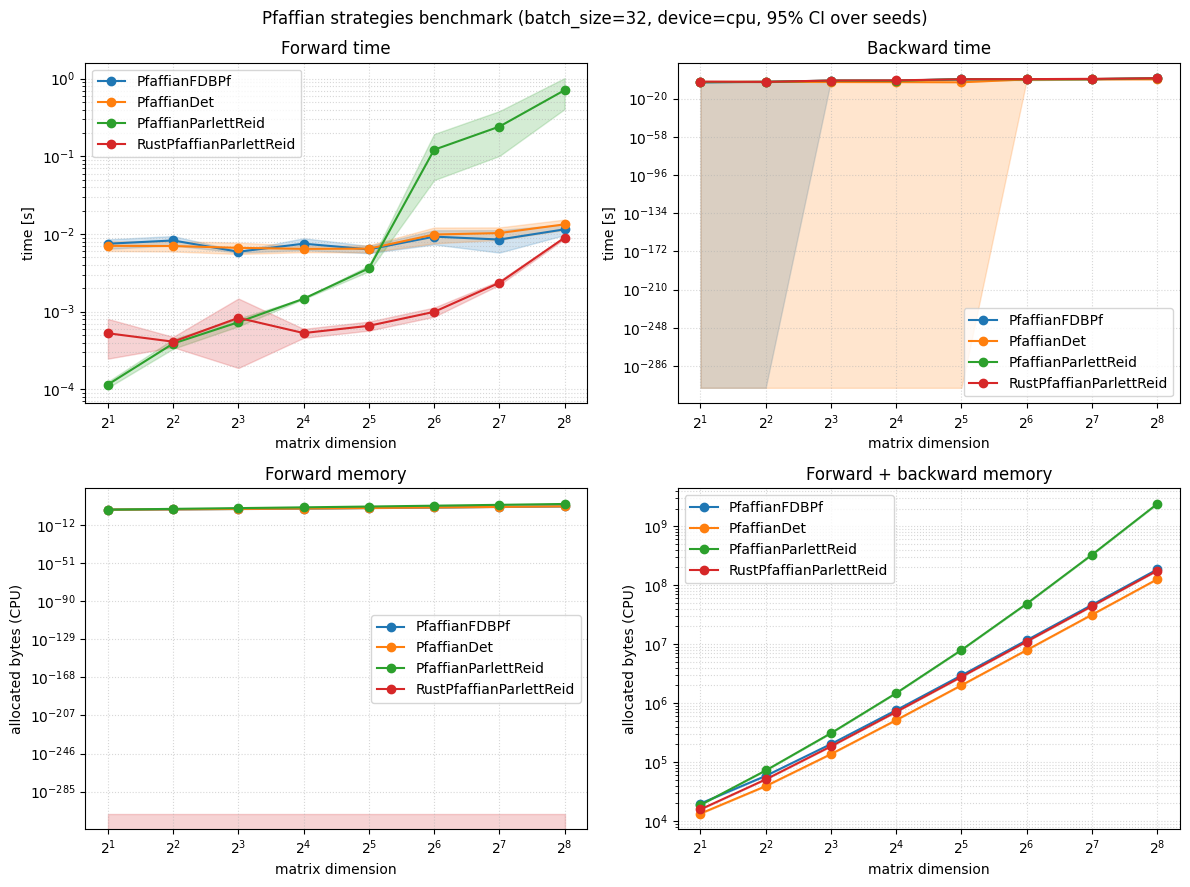

In [3]:
fig = plot_results(results, strategies, batch_size, device=device)

## Conclusions and caveats

The figure above reports, as a function of the matrix dimension $n$, the median forward time, the median backward time, the forward peak memory, and the combined forward + backward peak memory for every strategy. The general-purpose strategies are evaluated on general random skew-symmetric matrices; `PfaffianBlockDet`, when included, is evaluated on block-antidiagonal skew matrices (the only inputs for which it is valid). Shaded bands are 95% confidence intervals over the random seeds (they are essentially invisible for memory, which is seed-independent for a fixed shape).

**Memory-metric caveat.** The memory numbers depend on the device:

- On **CUDA**, the reported value is a true peak obtained from `torch.cuda.reset_peak_memory_stats()` / `torch.cuda.max_memory_allocated()`.
- On **CPU** (the continuous-integration case), no equivalent peak counter exists, so we report the **allocated bytes** measured by `torch.profiler` instead. This is an aggregate of allocations rather than a strict instantaneous peak, so CPU and CUDA memory values are not directly comparable and the absolute CPU numbers should be read as a relative indicator across strategies and sizes.

`PfaffianFDBPf` and `PfaffianDet` share the same forward (`sqrt(|det(A)|)`); their difference is the backward, so the backward panels highlight the analytic custom backward against plain autograd.